# S4307 — EDA exhaustive : Condition Monitoring Hydraulique

Dataset **fault-primary, drift-secondary** (ZeMA/UCI) : ~17 features de cycle, cycles **segmentés par
la condition du refroidisseur** (cooler ∈ {3, 20, 100} %), label de **faute** binaire (`stable_flag`).
Deux axes distincts :

- **structure de faute** → `_label` ∈ {0, 1} ;
- **dérive de régime** → `_segment` (condition cooler).

Tout sort du loader + `characterization.json` (S4303). Normalisation **figée sur le segment 0**
(héritée du loader `freeze_zscore`) — pas de re-fit. Skip gracieux si `data/raw/` absent.

In [1]:
import json, os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from sklearn.feature_selection import mutual_info_classif

# Racine projet (remonte jusqu'à pyproject.toml — robuste au CWD nbconvert)
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)  # les loaders utilisent des chemins relatifs à la racine du dépôt

from src.figures.style import apply_style          # déclenche matplotlib.use("Agg")
from src.utils.reproducibility import set_seed
from src.utils.config_loader import load_config
from src.data.hydraulic_dataset import load
from src.evaluation.eda_plots import (
    plot_label_distribution, plot_histograms_by_label, plot_boxplots_by_label,
    plot_violin_by_label, plot_kde_by_label, plot_temporal_by_label,
    plot_boxplots_by_group_and_label, plot_violin_by_group_and_label,
    plot_kde_by_group_and_label,
)
from src.evaluation.feature_space_plots import fit_pca2d, fit_tsne2d, plot_feature_space_2d

set_seed(42)          # reproductibilité (échantillonnage, t-SNE, MI)
apply_style("slide")  # rcParams cohérents avec la galerie S4305

CONFIG  = ROOT / "configs/hydraulic_drift_config.yaml"
CHAR    = ROOT / "experiments/exp_S43_drift_char/hydraulic/characterization.json"
FIG_DIR = ROOT / "notebooks/cl_eval/drift_datasets/figures/eda/hydraulic"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg = load_config(str(CONFIG))
RAW = ROOT / cfg["data"]["raw_path"]


def load_char():
    """Résumé S4303 (None si absent — pas de crash)."""
    if not CHAR.exists():
        return None
    return json.loads(CHAR.read_text(encoding="utf-8"))


def show(fig, name):
    """Sauvegarde le PNG puis l'affiche inline (backend Agg → display(Image), cf. S4305)."""
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(str(path)))


def scatter_by_category(ax, coords, cats, title, legend_title,
                        cmap="tab10", continuous=False):
    """Scatter 2D coloré par catégorie (helper local : plot_feature_space_2d est
    limité aux labels binaires + 3 noms de domaine figés Pump/Turbine/Compressor ;
    pour l'axe DÉRIVE multi-catégorie on reprend le scatter inline de eda_paderborn)."""
    cats = np.asarray(cats)
    if continuous:
        sc = ax.scatter(coords[:, 0], coords[:, 1], c=cats, cmap=cmap,
                        s=6, alpha=0.4, linewidths=0)
        cb = ax.figure.colorbar(sc, ax=ax)
        cb.set_label(legend_title)
    else:
        cm = plt.get_cmap(cmap)
        for i, u in enumerate(sorted(np.unique(cats))):
            m = cats == u
            ax.scatter(coords[m, 0], coords[m, 1], s=6, alpha=0.4, linewidths=0,
                       color=cm(i % cm.N), label=f"{legend_title} {u}")
        ax.legend(fontsize=8, markerscale=2, ncol=2, loc="best")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2"); ax.grid(alpha=0.3)


char = load_char()
DATA_OK = RAW.exists()
if not DATA_OK:
    display(Markdown(
        f"> ⚠️ **Données brutes absentes** (`{RAW}`). Notebook en mode dégradé : "
        f"les figures dépendant de `data/raw/` sont omises proprement. "
        f"Le résumé S4303 (JSON) reste lisible ci-dessous."))
if char is None:
    display(Markdown("> ⚠️ Caractérisation S4303 absente — lancer `scripts/characterize_drift.py`."))

✅ Seed fixé à 42


## 1. Chargement & vue d'ensemble

In [2]:
if DATA_OK:
    ds = load(str(CONFIG))
    df = pd.DataFrame(ds.X, columns=ds.feature_names)
    df["_label"] = ds.y                       # faute 0/1 (stable_flag)
    seg = np.zeros(ds.n_samples, dtype=int)
    for i, (s, e) in enumerate(ds.segments):
        seg[s:e] = i
    df["_segment"] = seg                      # condition cooler (index de segment)
    df["_t"] = np.arange(ds.n_samples)
    seg_values = ds.metadata.get("segment_values", [])
    TOP = [f["feature"] for f in char["features_most_drifted"][:6]]
    print(f"X={ds.X.shape} | {len(ds.segments)} conditions cooler={seg_values} | "
          f"faute base rate={df['_label'].mean():.2%}")
    display(Markdown("**17 capteurs de cycle :** " + ", ".join(f"`{c}`" for c in ds.feature_names)))

X=(2205, 17) | 3 conditions cooler=[3.0, 20.0, 100.0] | faute base rate=34.29%


**17 capteurs de cycle :** `PS1_mean`, `PS2_mean`, `PS3_mean`, `PS4_mean`, `PS5_mean`, `PS6_mean`, `EPS1_mean`, `FS1_mean`, `FS2_mean`, `TS1_mean`, `TS2_mean`, `TS3_mean`, `TS4_mean`, `VS1_mean`, `CE_mean`, `CP_mean`, `SE_mean`

In [3]:
if char is not None:
    top = ", ".join(f"`{f['feature']}` (KS={f['mean_ks']:.2f})"
                    for f in char["features_most_drifted"][:5])
    maha = char["series"]["mahalanobis"]
    peak = max(range(len(maha)), key=lambda k: maha[k])
    align = char.get("alignment_score")
    align_txt = "`null` (pas de vérité-terrain ponctuelle)" if align is None else f"{align:.0f}"
    display(Markdown(
        f"**Résumé S4303 — Hydraulique**\n\n"
        f"- Drift confirmé : `{char['drift_type_confirmed']}` · "
        f"{char['n_samples']} échantillons × {char['n_features']} features\n"
        f"- Axe dérive (conditions cooler) : {len(ds.segments) if DATA_OK else 'N/A'} segment(s)\n"
        f"- Features les plus dérivées : {top}\n"
        f"- Pic Mahalanobis à la fenêtre centrée sur `t={char['window_centers'][peak]}` "
        f"(magnitude {maha[peak]:.1f})\n"
        f"- Score d'alignement pic↔vérité-terrain : {align_txt}"))

**Résumé S4303 — Hydraulique**

- Drift confirmé : `incremental` · 2205 échantillons × 17 features
- Axe dérive (conditions cooler) : 3 segment(s)
- Features les plus dérivées : `PS6_mean` (KS=0.88), `PS5_mean` (KS=0.88), `TS4_mean` (KS=0.87), `TS1_mean` (KS=0.87), `TS3_mean` (KS=0.86)
- Pic Mahalanobis à la fenêtre centrée sur `t=2100` (magnitude 1040.1)
- Score d'alignement pic↔vérité-terrain : 152

## 2. Statistiques descriptives (par condition et par faute)

In [4]:
if DATA_OK:
    display(Markdown("**Moyenne des capteurs dérivés — par condition cooler (dérive de régime) :**"))
    display(df.groupby("_segment")[TOP].mean().round(2))
    display(Markdown("**Moyenne — par label de faute :**"))
    display(df.groupby("_label")[TOP].mean().round(2))

**Moyenne des capteurs dérivés — par condition cooler (dérive de régime) :**

,PS6_mean,PS5_mean,TS4_mean,TS1_mean,TS3_mean,TS2_mean
_segment,,,,,,
0,-0.00,-0.00,0.00,0.00,-0.00,0.00
1,3.78,3.76,-3.65,-3.38,-3.12,-3.37
2,9.25,9.19,-7.57,-6.78,-6.26,-6.82


**Moyenne — par label de faute :**

,PS6_mean,PS5_mean,TS4_mean,TS1_mean,TS3_mean,TS2_mean
_label,,,,,,
0,4.31,4.28,-3.70,-3.34,-3.08,-3.38
1,4.48,4.45,-3.87,-3.51,-3.25,-3.48


## 3. Distribution de la faute + taux de faute par condition cooler

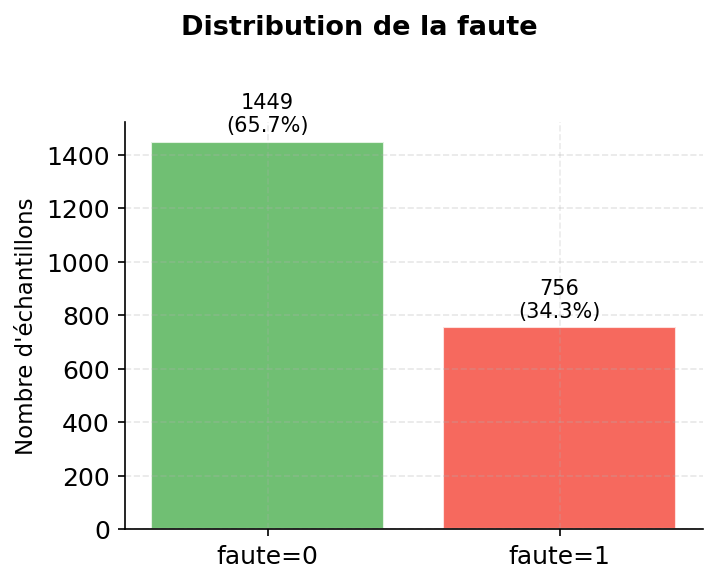

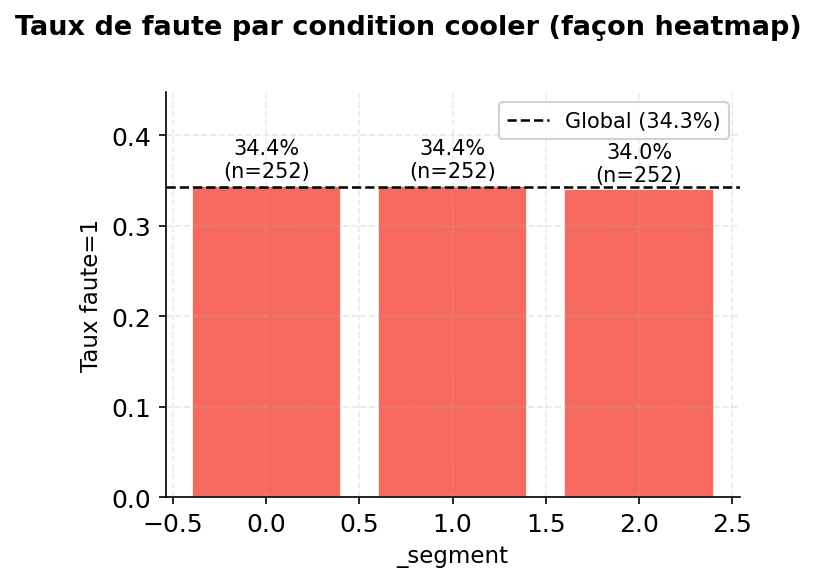

,taux_faute_%
_segment,
0,34.43
1,34.43
2,34.01


In [5]:
if DATA_OK:
    show(plot_label_distribution(df, "_label", label_name="faute",
         title="Distribution de la faute"), "label_dist_faute")
    show(plot_label_distribution(df, "_label", group_col="_segment", label_name="faute",
         title="Taux de faute par condition cooler (façon heatmap)"), "fault_rate_par_condition")
    # Table calculée (non recopiée)
    rate = (df.groupby("_segment")["_label"].mean() * 100).round(2).rename("taux_faute_%")
    display(rate.to_frame())

## 4. Distributions de features — faute (label) vs régime (condition cooler)

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fixe

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)


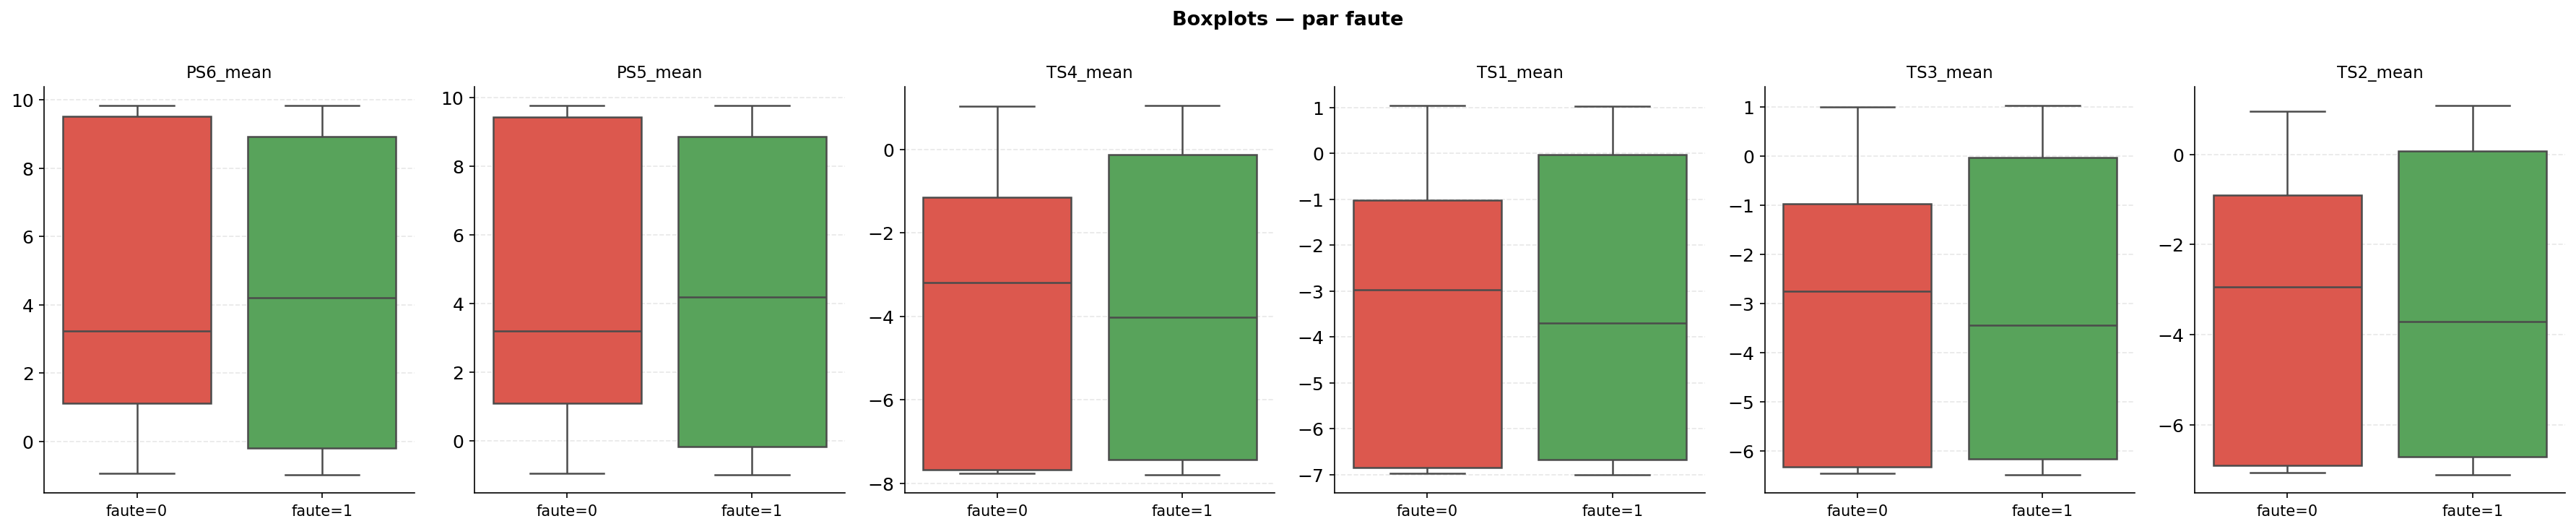

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or us

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:235: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:226: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the

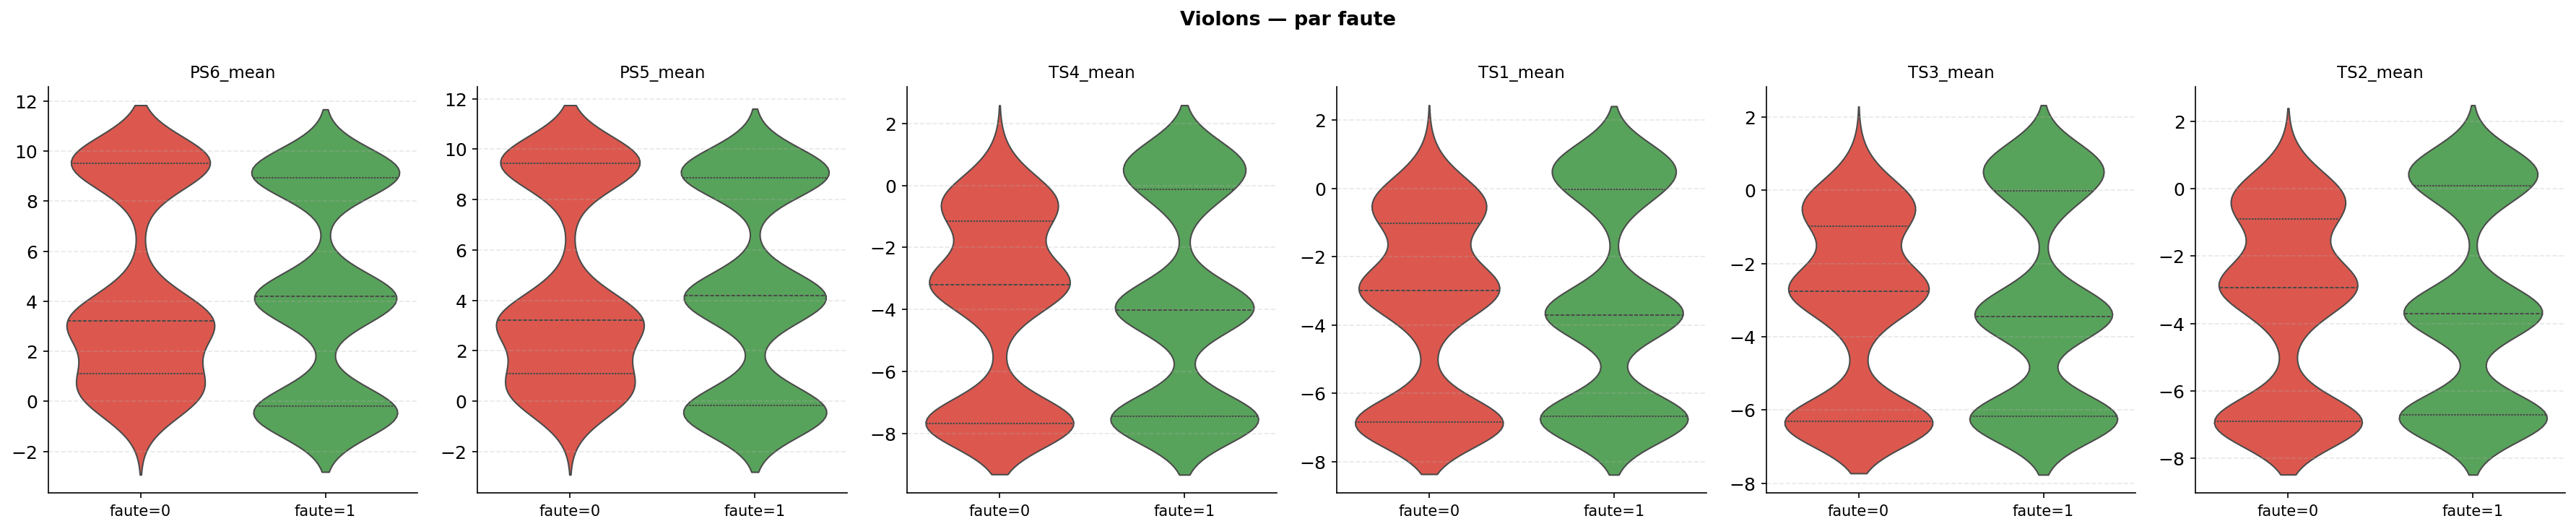

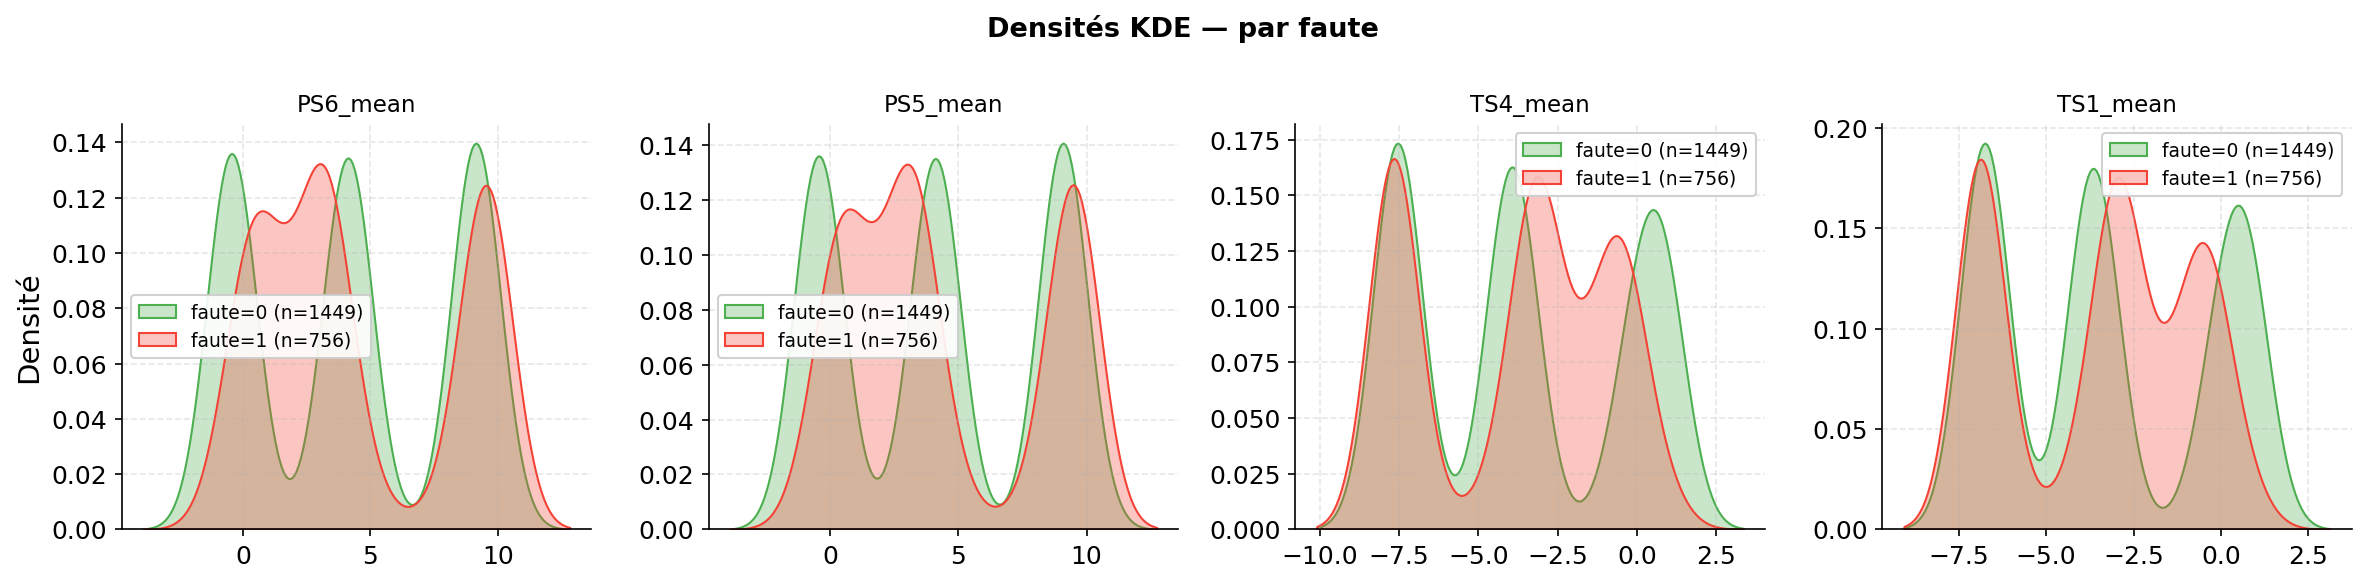

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:652: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:661: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:652: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:661: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/h

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:661: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:652: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:661: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:652: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/h

/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:661: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:652: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:661: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(
/home/leonard/Documents/ENAC/cl-embedded/src/evaluation/eda_plots.py:652: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/h

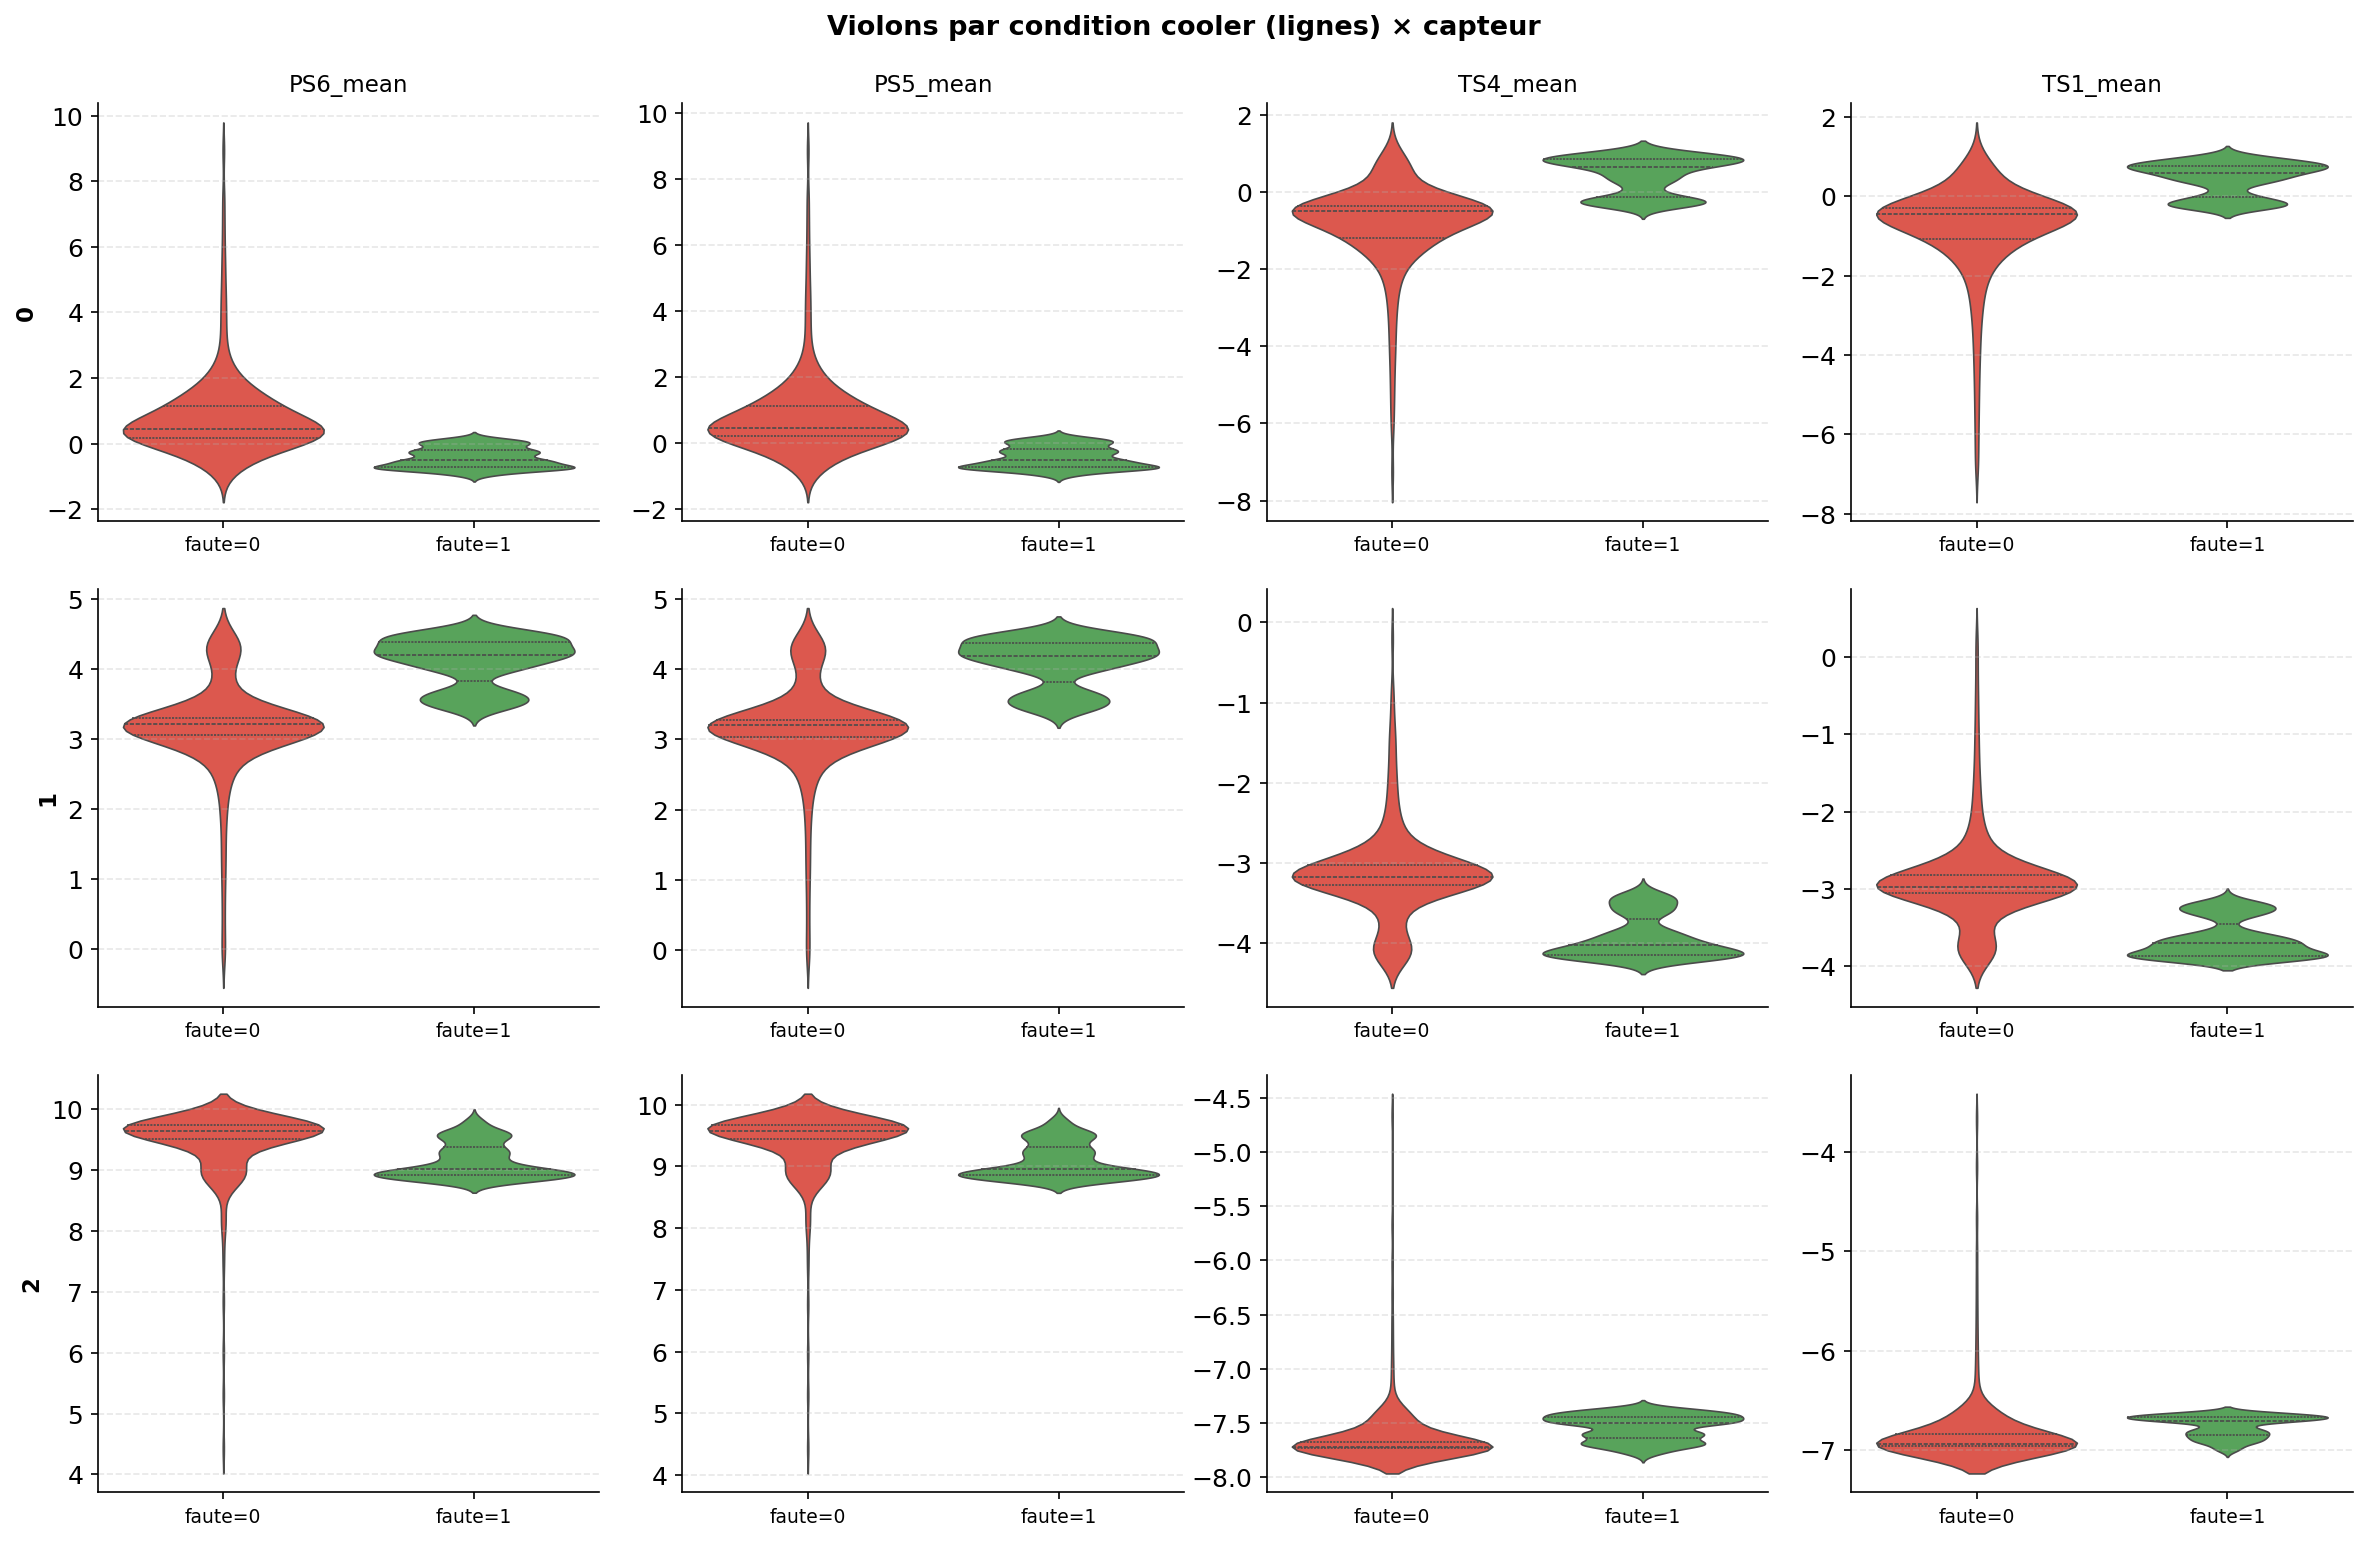

In [6]:
if DATA_OK:
    show(plot_boxplots_by_label(df, TOP, "_label", label_name="faute",
         title="Boxplots — par faute"), "box_by_faute")
    show(plot_violin_by_label(df, TOP, "_label", label_name="faute",
         title="Violons — par faute"), "violin_by_faute")
    show(plot_kde_by_label(df, TOP[:4], "_label", label_name="faute",
         title="Densités KDE — par faute"), "kde_by_faute")
    show(plot_violin_by_group_and_label(df, TOP[:4], "_label", "_segment",
         label_name="faute", title="Violons par condition cooler (lignes) × capteur"),
         "violin_condition_faute")

## 5. Corrélations inter-capteurs (familles pression / température / débit)

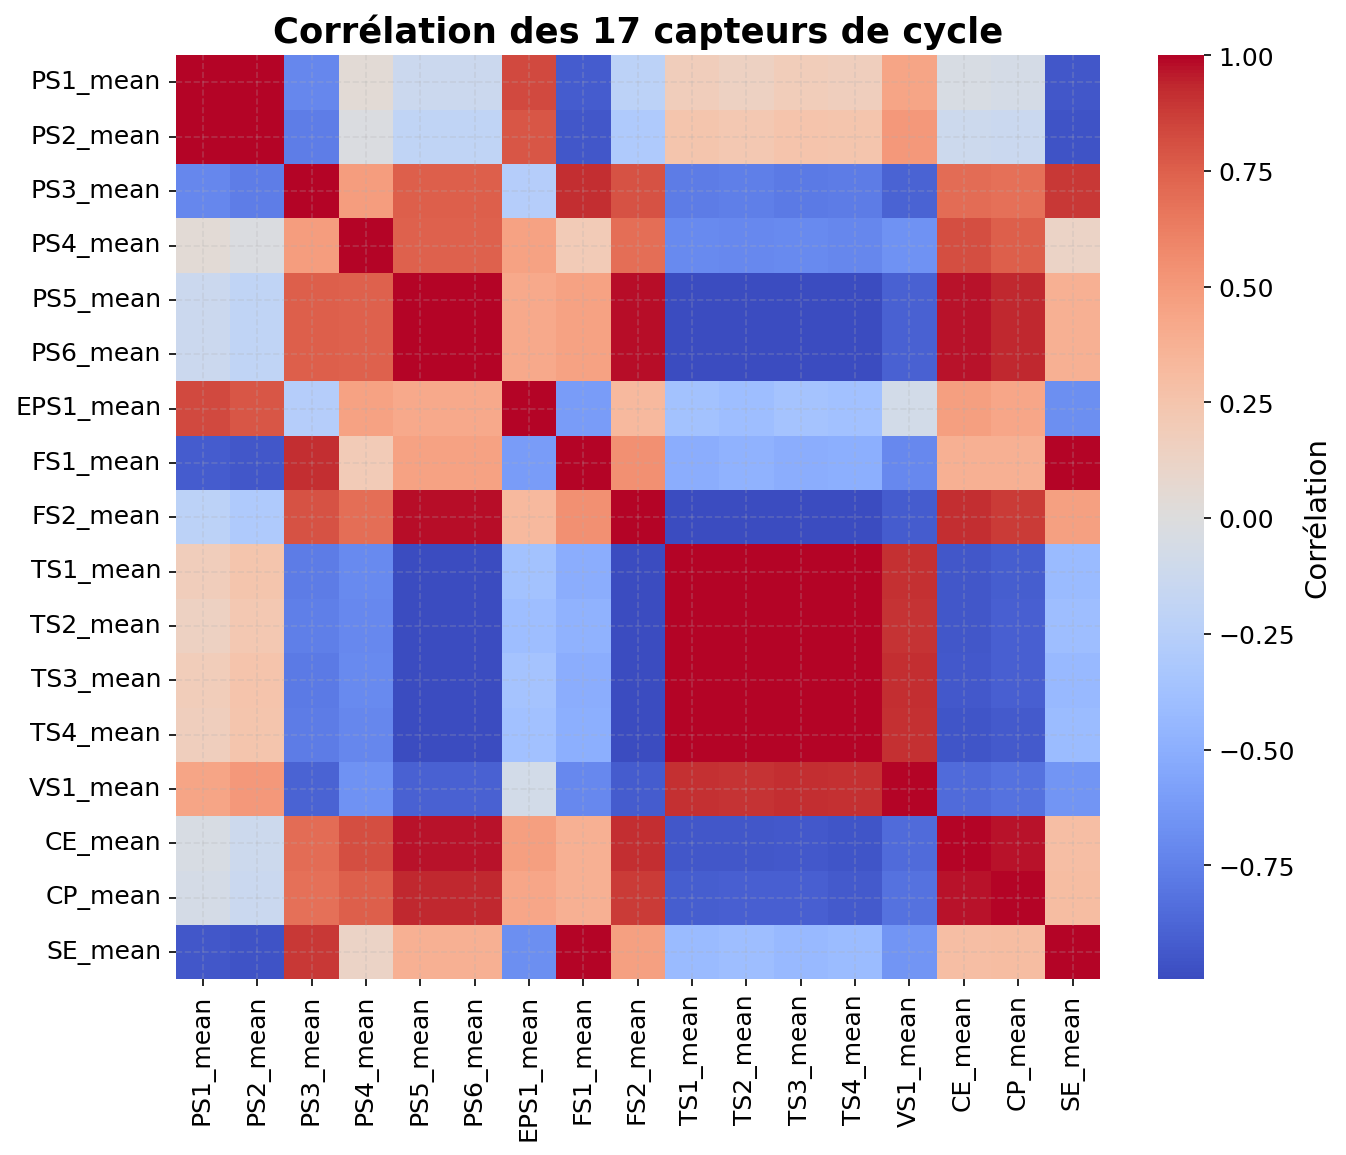

In [7]:
if DATA_OK:
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(df[ds.feature_names].corr(), cmap="coolwarm", center=0, ax=ax,
                square=True, annot=False, cbar_kws={"label": "Corrélation"})
    ax.set_title("Corrélation des 17 capteurs de cycle", fontweight="bold")
    show(fig, "corr_capteurs")

## 6. Projection 2D — par condition (dérive) puis par faute (séparabilité)

Le nuage par **faute** réutilise `plot_feature_space_2d` (label binaire = usage nominal du helper).
Le nuage par **condition** est un scatter inline multi-catégorie.

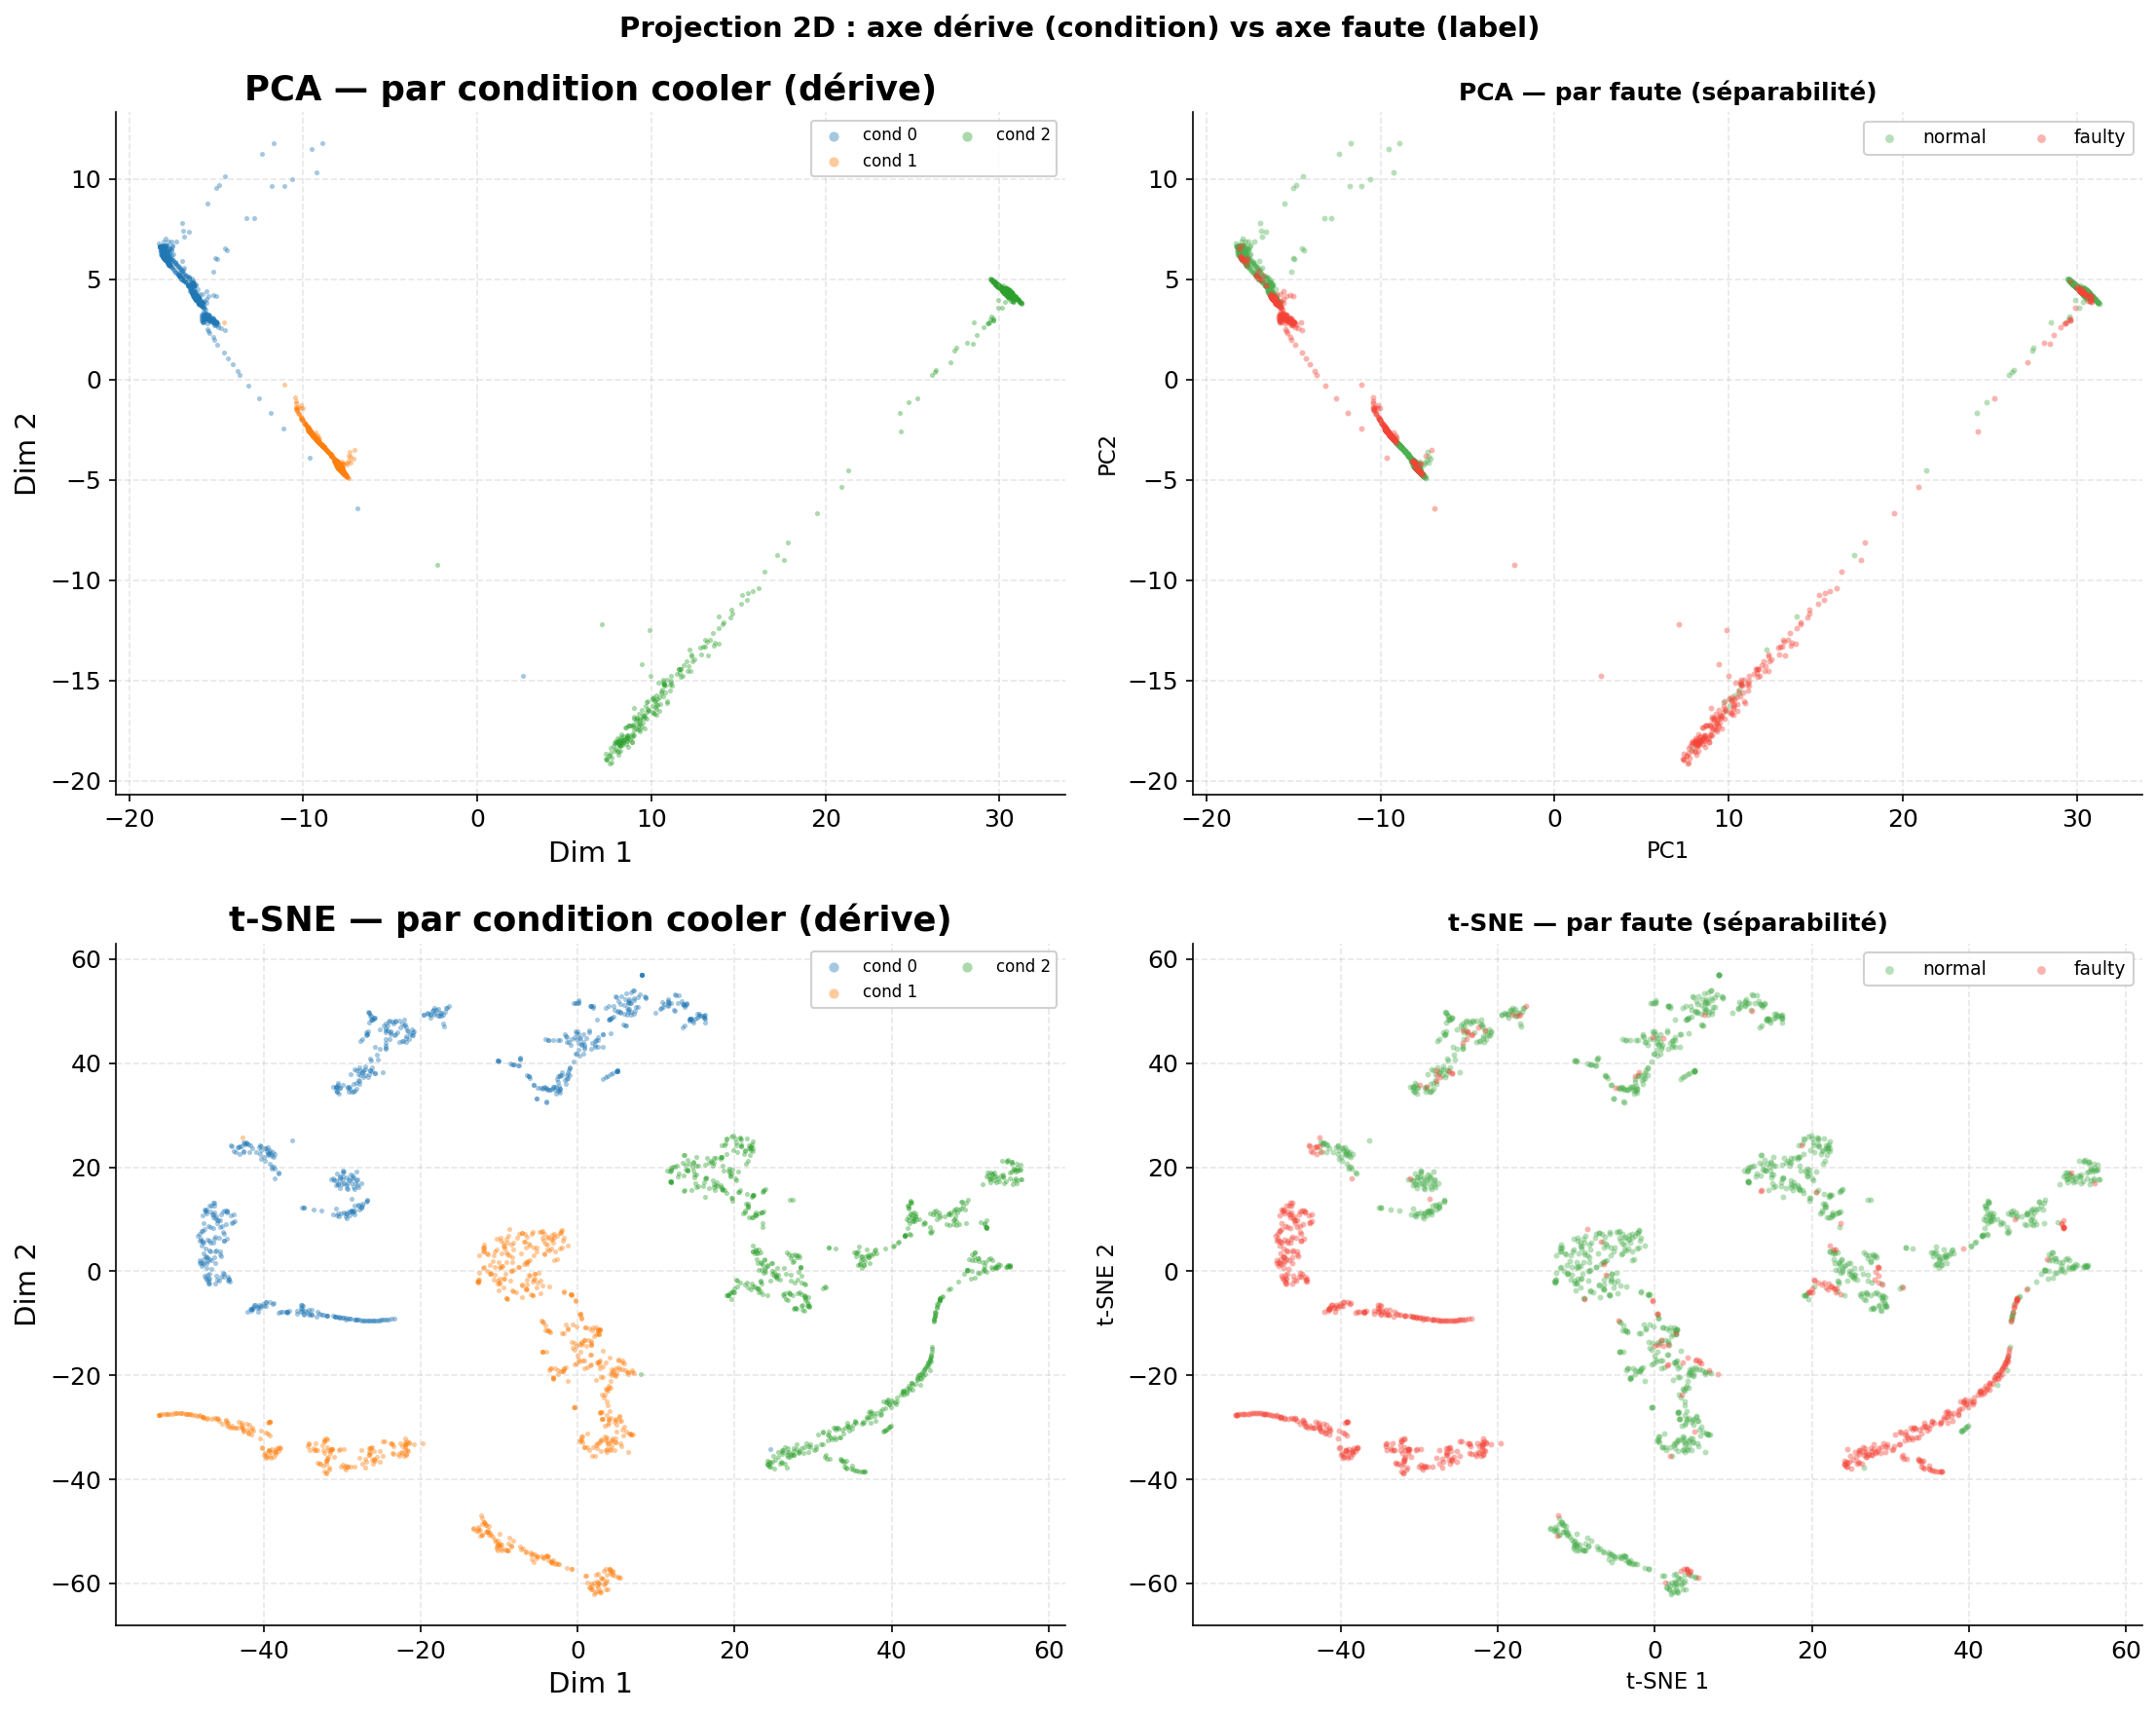

In [8]:
if DATA_OK:
    _, pca_xy = fit_pca2d(ds.X)
    _, tsne_xy = fit_tsne2d(ds.X, perplexity=30.0)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    scatter_by_category(axes[0, 0], pca_xy, seg, "PCA — par condition cooler (dérive)",
                        "cond", cmap="tab10")
    plot_feature_space_2d(pca_xy, ds.y, "PCA — par faute (séparabilité)", axes[0, 1],
                          xlabel="PC1", ylabel="PC2")
    scatter_by_category(axes[1, 0], tsne_xy, seg, "t-SNE — par condition cooler (dérive)",
                        "cond", cmap="tab10")
    plot_feature_space_2d(tsne_xy, ds.y, "t-SNE — par faute (séparabilité)", axes[1, 1],
                          xlabel="t-SNE 1", ylabel="t-SNE 2")
    fig.suptitle("Projection 2D : axe dérive (condition) vs axe faute (label)",
                 fontsize=14, fontweight="bold")
    fig.tight_layout()
    show(fig, "projection_2d")

## 7. Ranking d'importance des features vis-à-vis de la faute (mutual information)

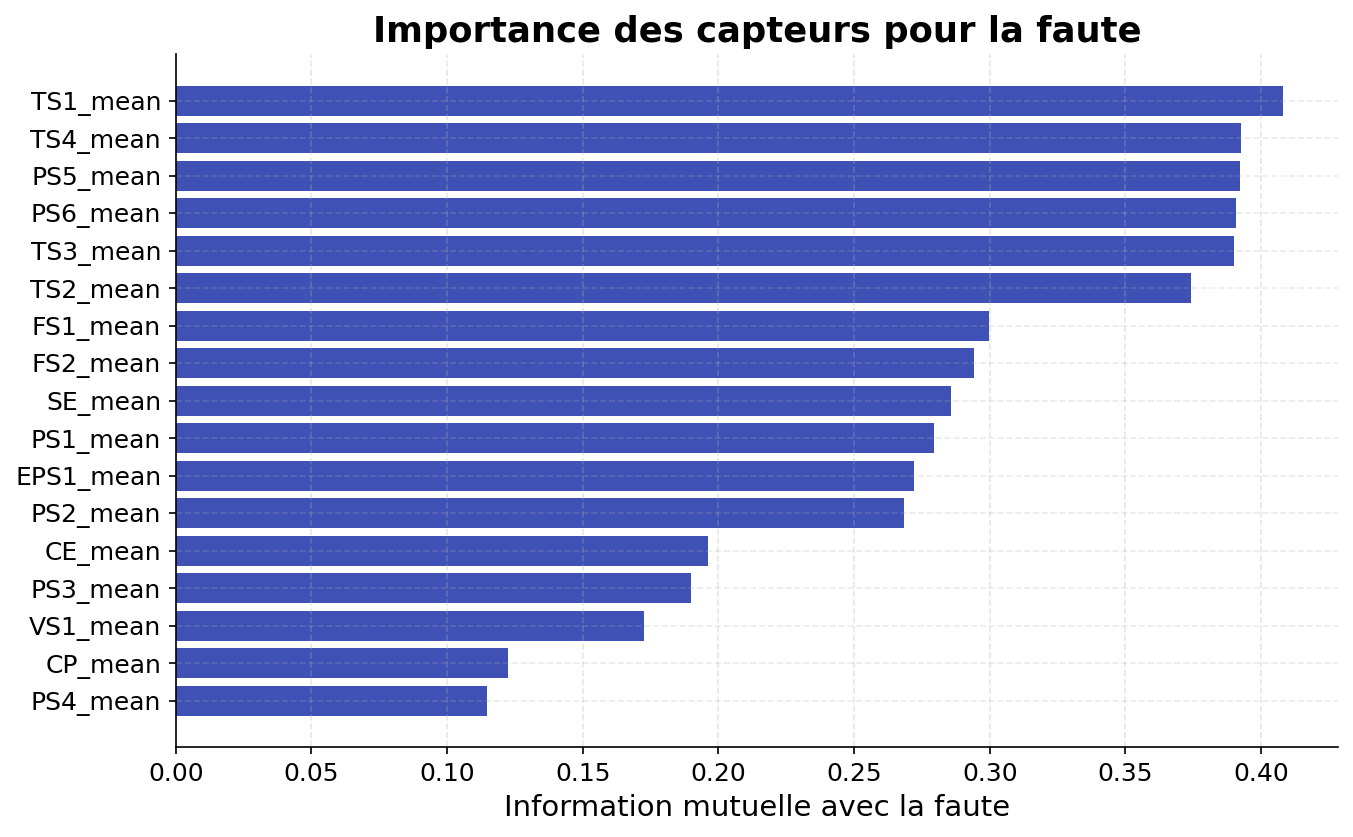

In [9]:
if DATA_OK:
    mi = mutual_info_classif(df[ds.feature_names].values, df["_label"].values, random_state=42)
    order = np.argsort(mi)[::-1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([ds.feature_names[i] for i in order][::-1], mi[order][::-1], color="#3F51B5")
    ax.set_xlabel("Information mutuelle avec la faute")
    ax.set_title("Importance des capteurs pour la faute", fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)
    show(fig, "mi_ranking")

## 8. Résumé pour le Sprint 44

- **Faute vs régime** : les capteurs à forte MI portent la faute ; les `features_most_drifted` (S4303)
  portent la dérive de régime cooler — les deux ensembles peuvent différer.
- **Tandem détecteur** : dataset adapté à l'évaluation conjointe **détecteur-drift** (segments cooler)
  **+ détecteur-faute** (label supervisé).
- **Dimension d'entrée** : 17 features → note **Gap 2/3**, largement portable sur MCU (coût borné).